<a href="https://colab.research.google.com/github/marcuslee6/Signal-and-Systems/blob/main/Second%20Order%20System%20Stability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Poles in s-plane: [-2.+9.79795897j -2.-9.79795897j]


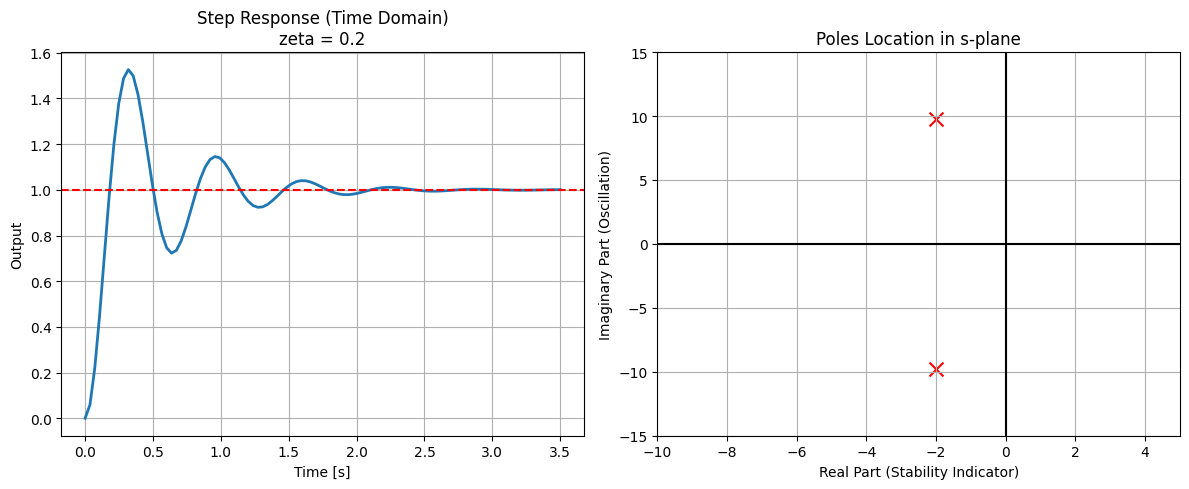

In [1]:
#Second-Order System Stability
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. Define System Parameters
wn = 10.0 # Natural Frequency
zeta = 0.2 # Damping Ratio
# zeta < 1: Underdamped: System oscillates with decreasing amplitude until eventually rest
# zeta = 0: Oscillate indefinitely at its natural frequency

# 2. Set up H(s)
# Numerator: [wn^2]
# Denominator: [1, 2*zeta*wn, wn^2] <-- with respect to s^2 + 2*zeta*wn*s + wn^2
num = [wn**2]
den = [1, 2*zeta*wn, wn**2]

sys = signal.TransferFunction(num, den)

# 3. Calculate poles
# In Laplace s-domain，If the values of the pole are negative real ，the system is stable
poles = sys.poles
print(f"Poles in s-plane: {poles}")

# 4. Step Response
t, y = signal.step(sys)

# 5. Plot graphs
plt.figure(figsize=(12, 5))

# Left graph：Time-Domain
plt.subplot(1, 2, 1)
plt.plot(t, y, lw=2)
plt.axhline(1, color='r', linestyle='--', label='Target')
plt.title(f"Step Response (Time Domain)\nzeta = {zeta}")
plt.xlabel("Time [s]")
plt.ylabel("Output")
plt.grid(True)

# Right Graph：s Poles Plot
plt.subplot(1, 2, 2)
plt.scatter(poles.real, poles.imag, color='red', marker='x', s=100)
plt.axvline(0, color='black', linestyle='-')
plt.axhline(0, color='black', linestyle='-')
plt.xlim(-10, 5)
plt.ylim(-15, 15)
plt.title("Poles Location in s-plane")
plt.xlabel("Real Part (Stability Indicator)")
plt.ylabel("Imaginary Part (Oscillation)")
plt.grid(True)

plt.tight_layout()
plt.show()